In [1]:
import pandas as pd

col_names = [
    'Fecha', 'Hora', 'Zona de Carga',
    'Precio Zonal ($/MWh)', 'Componente energia ($/MWh)',
    'Componente perdidas ($/MWh)',
    'Extra1', 'Extra2', 'Extra3'   # correcting column names since there are 3 unnamed columns
]
df = pd.read_csv('C:/Users/Dianalaura Cueto/Electricity Prices Forecast/data/Raw//Baja California/PreciosNodos_BCA_ABRIL16-30.csv',skiprows=8, header=None, names=col_names)

#Rows -1 = Zonas de carga data

In [2]:
print(df.shape)
print(df.head())

(1440, 9)
        Fecha  Hora Zona de Carga  Precio Zonal ($/MWh)  \
0  2026-04-16     1      ENSENADA                105.29   
1  2026-04-16     2      ENSENADA                104.09   
2  2026-04-16     3      ENSENADA                 94.03   
3  2026-04-16     4      ENSENADA                 94.16   
4  2026-04-16     5      ENSENADA                 94.37   

   Componente energia ($/MWh)  Componente perdidas ($/MWh)  Extra1  Extra2  \
0                      101.33                         3.96     0.0       0   
1                      100.15                         3.94     0.0       0   
2                       90.32                         3.71     0.0       0   
3                       90.38                         3.78     0.0       0   
4                       90.49                         3.88     0.0       0   

   Extra3  
0       1  
1       1  
2       1  
3       1  
4       1  


In [3]:
print(df.columns.tolist())

['Fecha', 'Hora', 'Zona de Carga', 'Precio Zonal ($/MWh)', 'Componente energia ($/MWh)', 'Componente perdidas ($/MWh)', 'Extra1', 'Extra2', 'Extra3']


In [4]:
print(df.dtypes) #check types of data in columns for energia we want float64 


Fecha                              str
Hora                             int64
Zona de Carga                      str
Precio Zonal ($/MWh)           float64
Componente energia ($/MWh)     float64
Componente perdidas ($/MWh)    float64
Extra1                         float64
Extra2                           int64
Extra3                           int64
dtype: object


In [5]:
#convert all columns except zona de carga to float
df["Zona de Carga"]=df["Zona de Carga"].astype(str)
df["Fecha"]=df["Fecha"].astype(str)
df["Hora"]=df["Hora"].astype(int)
colstype_convert = [col for col in df.columns if col not in ['Zona de Carga', 'Hora', 'Fecha']]
df[colstype_convert]= df[colstype_convert].astype(float)
print(df.dtypes)

Fecha                              str
Hora                             int64
Zona de Carga                      str
Precio Zonal ($/MWh)           float64
Componente energia ($/MWh)     float64
Componente perdidas ($/MWh)    float64
Extra1                         float64
Extra2                         float64
Extra3                         float64
dtype: object


In [6]:
#Checking for null and duplicates in a function.
#Automatically drops exact duplicate rows.
   

def clean_dataframe(df):
    
    print("=== Null values per column ===")
    print(df.isnull().sum())

    dup_count = df.duplicated().sum()
    print(f"\n=== Duplicate rows found: {dup_count} ===")

    if dup_count > 0:
        df = df.drop_duplicates()
        print("Duplicates removed.")
    else:
        print("No duplicates to remove.")

    return df
    

In [7]:
df = clean_dataframe(df)

=== Null values per column ===
Fecha                          0
Hora                           0
Zona de Carga                  0
Precio Zonal ($/MWh)           0
Componente energia ($/MWh)     0
Componente perdidas ($/MWh)    0
Extra1                         0
Extra2                         0
Extra3                         0
dtype: int64

=== Duplicate rows found: 0 ===
No duplicates to remove.


In [8]:
zonas=df["Zona de Carga"].unique()  # Numero de zonas de carga/ No. of zonas de carga
print(zonas)

<StringArray>
['ENSENADA', 'MEXICALI', 'SANLUIS', 'TIJUANA']
Length: 4, dtype: str


In [9]:
df["Hora"].min(), df["Hora"].max() # check hour range


(np.int64(1), np.int64(24))

In [10]:
df["Fecha"].min(),df["Fecha"].max() # check date range

('2026-04-16', '2026-04-30')

In [11]:
#export to csv
df.to_csv("C:/Users/Dianalaura Cueto/Electricity Prices Forecast/data/Clean/Baja California/PreciosNodos_BCA_ABRIL16-30_clean.csv", index=False, encoding='utf-8-sig')


In [12]:
rows = df.loc[ df['Precio Zonal ($/MWh)'].idxmax(), ['Zona de Carga', 'Hora']]

In [13]:
Highest=print(rows) # Zona de carga with the higest electricity price

Zona de Carga    ENSENADA
Hora                   15
Name: 302, dtype: object


In [14]:
row = df.loc[ df['Precio Zonal ($/MWh)'].idxmin(), ['Zona de Carga', 'Hora']]

In [15]:
Lowest=print(row)

Zona de Carga    MEXICALI
Hora                   11
Name: 34, dtype: object


In [16]:
meanprice= df.groupby('Zona de Carga')['Precio Zonal ($/MWh)'].mean() # group each zone , average their precio zonal and prints the zone with the higest price and the price
max_meanprice= meanprice.idxmax()
value_maxmean= meanprice.max()
maximo=print(max_meanprice)
print(value_maxmean)

ENSENADA
376.4394722222222


In [17]:
!pip install matplotlib


#This function creates individual plots for Zona de Carga via input 


import matplotlib.pyplot as plt
def inter_zone(df):

     Zona =input("Enter name of Zona de carga to plot (in all CAPS):") # write a zone of interest and plot the hourly price
     df_filterzone = df[df["Zona de Carga"] == Zona]
     df_filterzone.plot(x='Hora', y='Precio Zonal ($/MWh)', kind='line', marker='o', color='blue', figsize=(10, 5))
     plt.title(f"{Zona} HOURLY PRICES")
     plt.xlabel('Time (HR)')
     plt.ylabel('Price ($/MWh)')
     plt.grid(True)
     plt.show()
     return df



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: C:\Users\Dianalaura Cueto\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [18]:
#df_filter= inter_zone(df)  # Uncomment to request via input individual plots


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: C:\Users\Dianalaura Cueto\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
Index(['Fecha', 'Hora', 'Zona de Carga', 'Precio Zonal ($/MWh)',
       'Componente energia ($/MWh)', 'Componente perdidas ($/MWh)', 'Extra1',
       'Extra2', 'Extra3'],
      dtype='str')


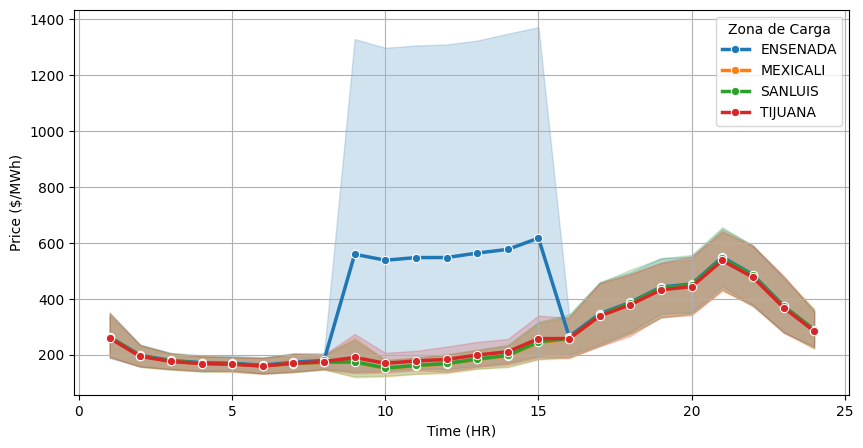

In [19]:
#plot all
%pip install seaborn
import matplotlib.pyplot as plt
import seaborn as sns #need seaborn to filter zones in an easy way adding a 3rd dimension but just plot 2 dimensions
print(df.columns)
plt.figure(figsize=(10, 5))
sns.lineplot(df,x='Hora', y='Precio Zonal ($/MWh)', hue='Zona de Carga', marker='o', linewidth=2.5) # "hue" filters the unique zones in  Zona de Carga
plt.xlabel('Time (HR)')
plt.ylabel('Price ($/MWh)')
plt.grid(True)
plt.show()